In [1]:
import torch
import numpy as np
from load_dataset import LoadDataset
from model import MLP
from torch.utils.data import DataLoader
from training import Trainer
from metrics import Evaluator
from gradients import GradMonitor
from activation_monitor import ActivationMonitor
import matplotlib.pyplot as plt  

In [2]:
iris_path = '/home/jessica/knowledge_distillation/first_experiments/dataset/iris.csv'
iris = LoadDataset(iris_path)
iris.load()
train_data, test_data = iris.split_dataset()

In [3]:
train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [5]:
config_prof = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [6]:
def activation_ordered(log):
    """
    Concatena (não stack!) ao longo da dimensão de amostra.
    Cada entrada de log é um batch; queremos um tensor único
    (N_total, dim) por layer, e (N_total,) para os labels.
    """
    resume = {'pred_labels': []}
    for info in log:
        resume['pred_labels'].append(info['pred_labels'])
        for layer in info['activations']:
            if layer not in resume:
                resume[layer] = []
            resume[layer].append(info['activations'][layer])
    for key in resume:
        resume[key] = torch.cat(resume[key], dim=0)
    idx = np.argsort(resume['pred_labels'].cpu().numpy())
    for key in resume:
        resume[key] = resume[key][idx]
    return resume

In [7]:
def grad_ordered(log):
    resume = {'pred_labels': []}
    for info in log:
        pred_labels = info['pred_labels']
        resume['pred_labels'].append(pred_labels)
        for layer in info['grads']:
            if layer not in resume:
                resume[layer] = []
            resume[layer].append(info['grads'][layer])


    for key in resume:
        resume[key] = torch.cat(resume[key], dim=0)
    id_order = np.argsort(resume['pred_labels'].cpu().numpy())
    for key in resume:
        resume[key] = resume[key][id_order]
    return resume

In [8]:
def entropy(p):
    p = p[p > 0]  # Evitar log(0)
    return -np.sum(p * np.log(p))

def entropy_activation(log_activations, nbins=10):
    entropies = {}
    unique_labels = np.unique(log_activations['pred_labels'].cpu().numpy())
    for layer, acts in log_activations.items():
        if 'relu' in layer.lower():
            entropies[layer] = {}
            nneurons = acts.shape[1]
            for neuron in range(nneurons):
                entropies[layer][neuron] = {}
                acts_neuron = acts[:, neuron:neuron+1]
                edges = np.linspace(acts_neuron.min(), acts_neuron.max(), num=nbins)  # 10 bins
                for y in unique_labels:
                    mask = log_activations['pred_labels'] == y
                    acts_y = acts_neuron[mask]
                    counts, _ = np.histogram(acts_y.cpu().numpy(), bins=edges)
                    p = counts / counts.sum()
                    entropies[layer][neuron][y] = entropy(p)

    return entropies

In [ ]:
# experimento simulando o colapso neural de uma rede iris MLP 
# após a acurácia ir para zero, vou treinar até a loss ir para zero,ouuu
# até 10 vezes a quantide de épocas que a acurácia foi para zero, o que vier primeiro.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
teacher = MLP(config_prof).to(device)
trainer = Trainer(teacher, config_prof)
patience = 0
log_grads_history = []
activations_history = []
stop = False
epochs = 0
first = False
while not stop:
    epochs += 1
    loss, log_grads = trainer.train_epoch(train_loader, detch_grad=True)
    log_grads_history.append(log_grads)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    if ptrain == 0:  # Convergence check
        if not first:
            first = True
            print(epochs)
        patience +=1 

    if loss == 0 or patience > 10* epochs:
        stop = True
    
    activations = ActivationMonitor(teacher, config_prof)
    log_activations = activations.get_activations(train_loader)
    log_activations_ordered = activation_ordered(log_activations)
    activations_history.append(log_activations_ordered)

print( Evaluator(teacher).accuracy(train_loader),  Evaluator(teacher).accuracy(test_loader))


In [ ]:
def get_entropy_classes(entropy_history, log_activations_ordered):
    classes = np.unique(log_activations_ordered['pred_labels'].cpu().numpy())
    entropy_classes = {}
    for i in range(len(entropy_history)):
        for layer in entropy_history[i]:
            if i==0:
                entropy_classes[layer] = {}
            for neuron in entropy_history[i][layer]:
                if i==0:
                    entropy_classes[layer][neuron] = {}
                    for y in classes:
                        entropy_classes[layer][neuron][y] = [0]
                else:
                    for y in classes:
                        entropy_classes[layer][neuron][y].append(0)
                for y in entropy_history[i][layer][neuron]:
                    entropy_classes[layer][neuron][y][i] = entropy_history[i][layer][neuron][y]
    return entropy_classes, classes

In [22]:
torch.stack(log_grads_history[0]['grads']['layers.fc1.weight'], dim=0).shape 
# log_grads_history[0]['grads']['layers.fc1.weight'][0].shape

torch.Size([105, 5, 4])

In [23]:
def ordering_grads(log_grad):

    try:
        log_grad['outputs'] = torch.cat(log_grad['outputs'], dim=0)
    except: 
        pass
    try:
        log_grad['targets'] = torch.cat(log_grad['targets'], dim=0)
    except:
        pass
    for layer in log_grad['grads']:
        try:
            log_grad['grads'][layer] = torch.stack(log_grad['grads'][layer], dim=0)
        except:
            pass

    idx = torch.argsort(log_grad['outputs'])
    for layer in log_grad['grads']:
        if 'bias' in layer: continue
        log_grad['grads'][layer] = log_grad['grads'][layer][idx]
    log_grad['outputs'] = log_grad['outputs'][idx]
    log_grad['targets'] = log_grad['targets'][idx]

for i in range(len(log_grads_history)):
    ordering_grads(log_grads_history[i]) 

In [30]:
from pruning_utils import compute_similarity_matrix


def compute_ang_grads(log_grad):
    ang_history = {}
    for i in range(len(log_grad)):
        ang_history[i] = {}
        ang_history[i]['outputs'] = log_grad[i]['outputs']
        for layer in log_grad[i]['grads']:
            if ('relu'  in layer.lower()) or ('bias' in layer.lower()): continue
            ang_history[i][layer] =compute_similarity_matrix(log_grad[i]['grads'][layer])

    return ang_history

mat_grad_history = compute_ang_grads(log_grads_history)


In [44]:
def get_indices_by_class(outputs):
    change_mask = np.diff(outputs) != 0
    change_indices = np.where(change_mask)[0] + 1
    indices = np.concatenate(([0], change_indices, [len(outputs)]))
    return indices

In [ ]:
def get_entropy_by_class(grad_matrix, nbins=10):
    class_entropies = {}
    for epoch in grad_matrix:
        class_entropies[epoch] = {}
        indices = get_indices_by_class(grad_matrix[epoch]['outputs'].cpu().numpy())
        for layer in grad_matrix[epoch]:
            if layer == 'outputs': continue
            class_entropies[epoch][layer] = {}
            for nneuron in range(grad_matrix[epoch][layer].shape[0]):
                class_entropies[epoch][layer][nneuron] = []
                edges = np.linspace(grad_matrix[epoch][layer][nneuron].min(), grad_matrix[epoch][layer][nneuron].max(), num=nbins)  # 10 bins
                for i in range(len(indices)-1):
                    start, end = indices[i], indices[i+1]
                    grad_subset = grad_matrix[epoch][layer][nneuron, start:end, start:end]
                    upper = torch.triu(grad_subset)
                    counts, _ = np.histogram(upper.cpu().numpy(), bins=edges)
                    p = counts / counts.sum()
                    class_entropies[epoch][layer][nneuron].append(entropy(p))
    return class_entropies


In [70]:
def grad_entropy(grad_matrix, nbins=10):
    class_entropies = {}
    for epoch in grad_matrix:
        class_entropies[epoch] = {}
        for layer in grad_matrix[epoch]:
            if layer == 'outputs': continue
            class_entropies[epoch][layer] = {}
            for nneuron in range(grad_matrix[epoch][layer].shape[0]):
                class_entropies[epoch][layer][nneuron] = []
                edges = np.linspace(grad_matrix[epoch][layer][nneuron].min(), grad_matrix[epoch][layer][nneuron].max(), num=nbins)  # 10 bins
                upper = torch.triu(grad_matrix[epoch][layer])
                counts, _ = np.histogram(upper.cpu().numpy(), bins=edges)
                p = counts / counts.sum()
                class_entropies[epoch][layer][nneuron].append(entropy(p))
    return class_entropies

In [74]:
def grad_entropies_between_classes(grad_matrix, nbins=10):
    class_entropies = {}
    for epoch in grad_matrix:
        class_entropies[epoch] = {}
        indices = get_indices_by_class(grad_matrix[epoch]['outputs'].cpu().numpy())
        for layer in grad_matrix[epoch]:
            if layer == 'outputs': continue
            class_entropies[epoch][layer] = {}
            for nneuron in range(grad_matrix[epoch][layer].shape[0]):
                class_entropies[epoch][layer][nneuron] = []
                edges = np.linspace(grad_matrix[epoch][layer][nneuron].min(), grad_matrix[epoch][layer][nneuron].max(), num=nbins)  # 10 bins
                for i in range(len(indices)-1):
                    start, end = indices[i], indices[i+1]
                    for j in range(i+1, len(indices)-1):
                        start_j, end_j = indices[j], indices[j+1]
                        grad_subset = grad_matrix[epoch][layer][nneuron, start:end, start_j:end_j]
                        upper = torch.triu(grad_subset)
                        counts, _ = np.histogram(upper.cpu().numpy(), bins=edges)
                        p = counts / counts.sum()
                    class_entropies[epoch][layer][nneuron].append(entropy(p))
    return class_entropies

In [ ]:
between_classes = grad_entropies_between_classes(mat_grad_history)
bhclass = {}
nclasses = 3
layer = 'layers.fc1.weight'
nneurons = len(between_classes[0][layer])
for i in range(nclasses):
    bhclass[i] = {}
    for neuron in range(nneurons):
        bhclass[i][neuron] = []
for neuron in range(nneurons):
    for epoch in between_classes:
        for i, ent in enumerate(between_classes[epoch][layer][neuron]):
            bhclass[i][neuron].append(ent)

In [84]:
entire_grad_entropy = grad_entropy(mat_grad_history)
ent_by_neuron = {neuron: [] for neuron in range(len(entire_grad_entropy[0]['layers.fc1.weight']))}
for epoch in entire_grad_entropy:
    for neuron in entire_grad_entropy[epoch]['layers.fc1.weight']:
        ent_by_neuron[neuron].append(entire_grad_entropy[epoch]['layers.fc1.weight'][neuron][0])

In [85]:
grad_entropies = get_entropy_by_class(mat_grad_history)
hclass = {}
nclasses = 3
nneurons = len(grad_entropies[0]['layers.fc1.weight'])
for i in range(nclasses):
    hclass[i] = {}
    for neuron in range(nneurons):
        hclass[i][neuron] = []
layer = 'layers.fc1.weight'
for neuron in range(nneurons):
    for epoch in grad_entropies:
        for i, ent in enumerate(grad_entropies[epoch][layer][neuron]):
            hclass[i][neuron].append(ent)

In [97]:
len(bhclass[0])

5

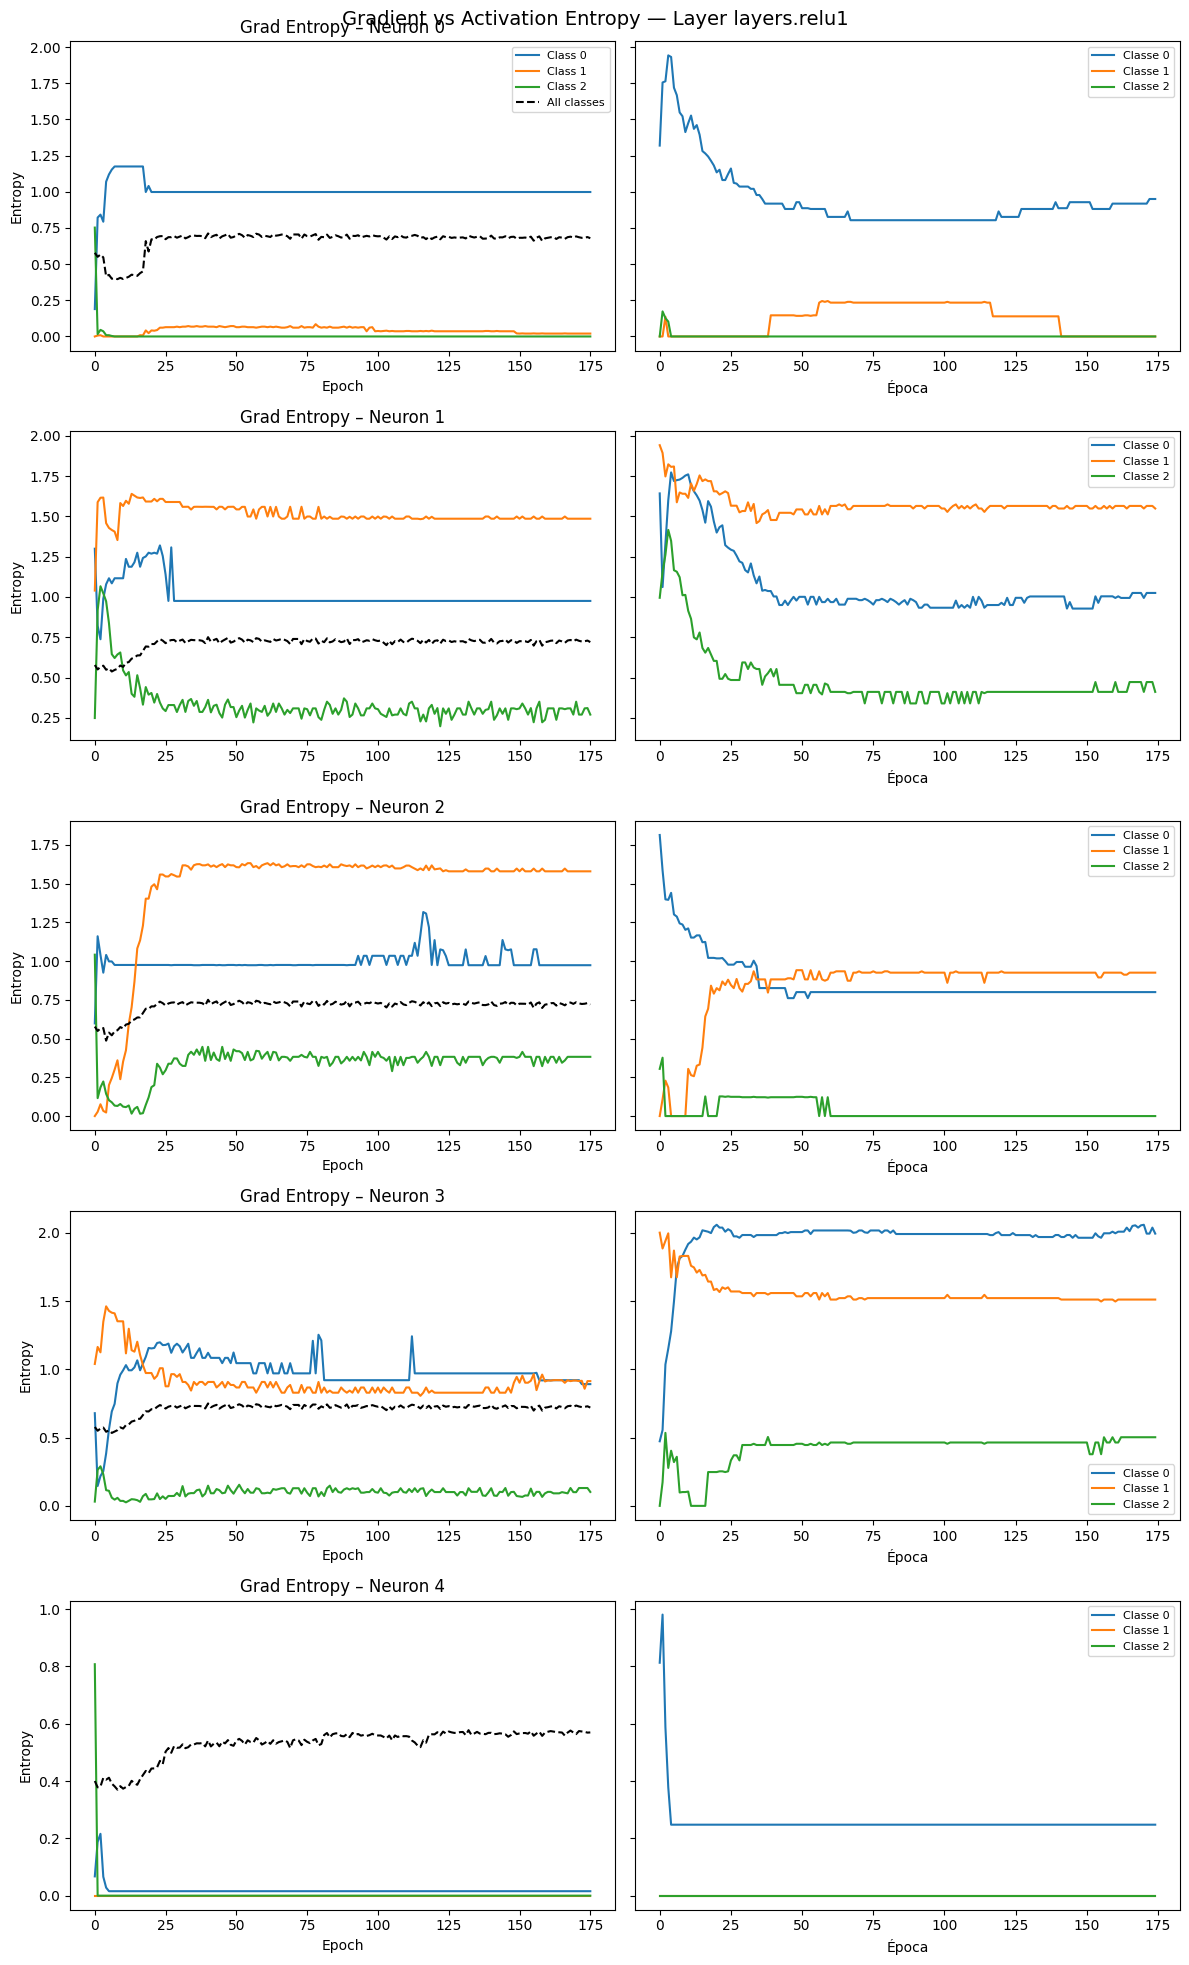

In [111]:
entropy_classes, classes = get_entropy_classes(entropy_history, log_activations_ordered)
layers = list(entropy_classes.keys())
l1 = layers[0]
neurons = list(entropy_classes[l1].keys())
n_neurons = len(neurons)

fig, axes = plt.subplots(n_neurons, 2, figsize=(12, 4 * n_neurons), sharey='row')
nomes_between = {
    0: 'Class 0 vs Class 1',
    1: 'Class 0 vs Class 2',
    2: 'Class 1 vs Class 2'
}
for i, neuron in enumerate(neurons):
    colors = {}
    # --- esquerda: entropia dos gradientes ---
    for c in range(nclasses):
        line, = axes[i, 0].plot(hclass[c][neuron], label=f'Class {c}')
        colors[c] = line.get_color()
        # axes[i, 0].plot(bhclass[c][neuron], label=nomes_between[c],
                        # linestyle='dashed', color=colors[c])


    axes[i,0].plot(ent_by_neuron[neuron], label='All classes', linestyle='--', color='black')
    axes[i, 0].set_title(f'Grad Entropy – Neuron {neuron}')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Entropy')
    if i == 0:
        axes[i, 0].legend(fontsize=8)

    # --- direita: entropia das ativações ---
    for y in classes:
        axes[i, 1].plot(entropy_classes[l1][neuron][y],
                        label=f'Classe {y}', color=colors[y])
        axes[i, 1].legend(fontsize=8)

    # axes[i, 1].set_title(f'Act Entropy – Neuron {neuron}')
    axes[i, 1].set_xlabel('Época')

fig.suptitle(f'Gradient vs Activation Entropy — Layer {l1}', fontsize=14)
plt.tight_layout()
plt.show()

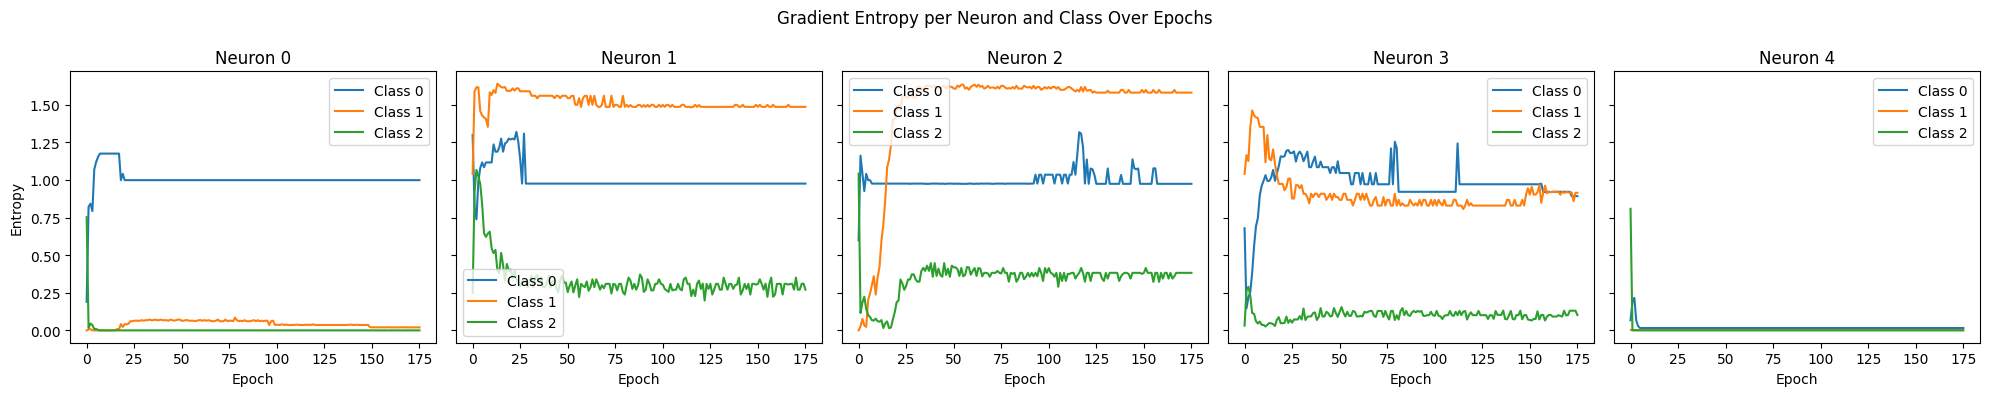

In [65]:
fig, axes = plt.subplots(1, nneurons, figsize=(4*nneurons, 4), sharey=True)

for neuron in range(nneurons):
    for i in range(nclasses):
        axes[neuron].plot(hclass[i][neuron], label=f'Class {i}')
    axes[neuron].set_title(f'Neuron {neuron}')
    axes[neuron].set_xlabel('Epoch')
    axes[neuron].legend()


axes[0].set_ylabel('Entropy')
plt.suptitle('Gradient Entropy per Neuron and Class Over Epochs')
plt.tight_layout()
plt.show()

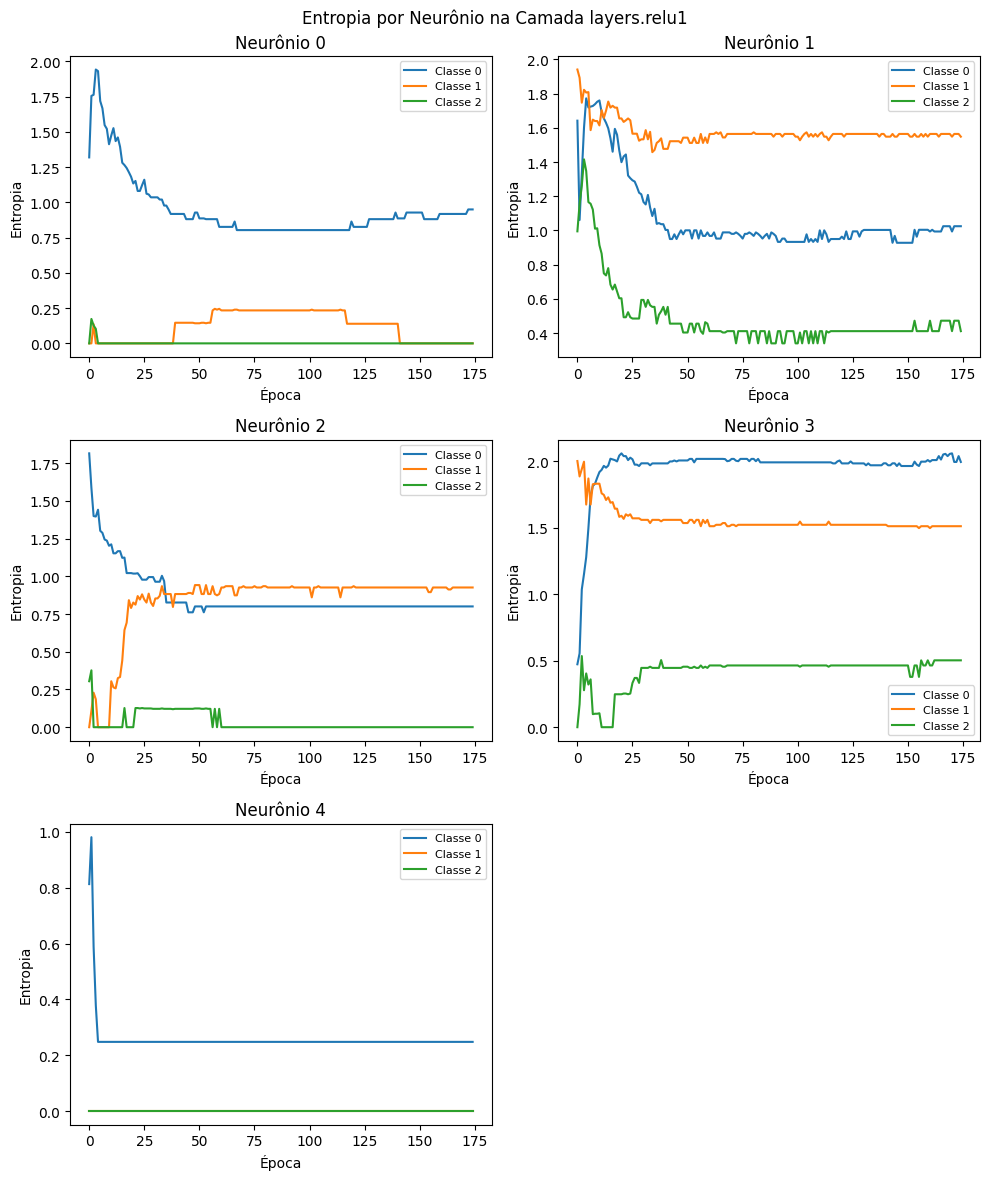

In [66]:
entropy_classes, classes = get_entropy_classes(entropy_history, log_activations_ordered)
layers = list(entropy_classes.keys())
l1 = layers[0]
neurons = list(entropy_classes[l1].keys())

n_neurons = len(neurons)
ncols = 2  # ajuste conforme preferir
nrows = int(np.ceil(n_neurons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, neuron in enumerate(neurons):
    ax = axes[i]
    for y in classes:
        ax.plot(entropy_classes[l1][neuron][y], label=f'Classe {y}')
    ax.set_title(f'Neurônio {neuron}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Entropia')
    ax.legend(fontsize=8)

# remove eixos vazios se n_neurons não for múltiplo de ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Entropia por Neurônio na Camada {l1}')
plt.tight_layout()
plt.show()

In [ ]:
teacher_monitor = GradMonitor(teacher, config_prof)
log_gradients = teacher_monitor.get_gradients(train_loader)
# log_gradients_ordered = grad_ordered(log_gradients)


In [ ]:
# se eu for pegar a entropia da formação geométricadas classes qq tenho eu que fazer:
# intra_classe ou inter_classe e ver como a entropia isso se comporta
log_teacher = log_gradients

In [ ]:
def get_student_model(T, c, teacher, train_loader, config, max_epochs=20000, patience=100, tol=1e-5):
    student = MLP(config).to(device)
    t_student = Trainer(student, config)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    sold = ptrain
    patience = 0
    entropy_history_student = []
    for k in range(max_epochs):
        t_student.train_student(teacher, train_loader, T=T, c=c)
        strain = Evaluator(student).accuracy(train_loader)
        if (abs(sold - strain)) < tol:  # Convergence check
           patience += 1
        else:
           patience = 0
       
        if patience >= 50:  # Early stopping after 5 epochs without improvement
            break
        sold = strain
        activations = ActivationMonitor(student, config)
        log_activations = activations.get_activations(train_loader)
        log_activations_ordered = activation_ordered(log_activations)
        entropy_history_student.append(entropy_activation(log_activations_ordered))
    return student, entropy_history_student

##### Será que as informações dentro as redes sao iguais? -> vou dar uma olhada nos gradientes
---

In [ ]:
config_student = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [ ]:
student, student_entropy_history = get_student_model(T=5, c=0.5, teacher=teacher, train_loader=train_loader, config=config_student)
student_monitor = GradMonitor(student, config_student)
log_student = student_monitor.get_gradients(train_loader) 
metrics_student = Evaluator(student)
print(metrics_student.accuracy(train_loader), metrics_student.accuracy(test_loader))

0.9809523809523809 0.9555555555555556


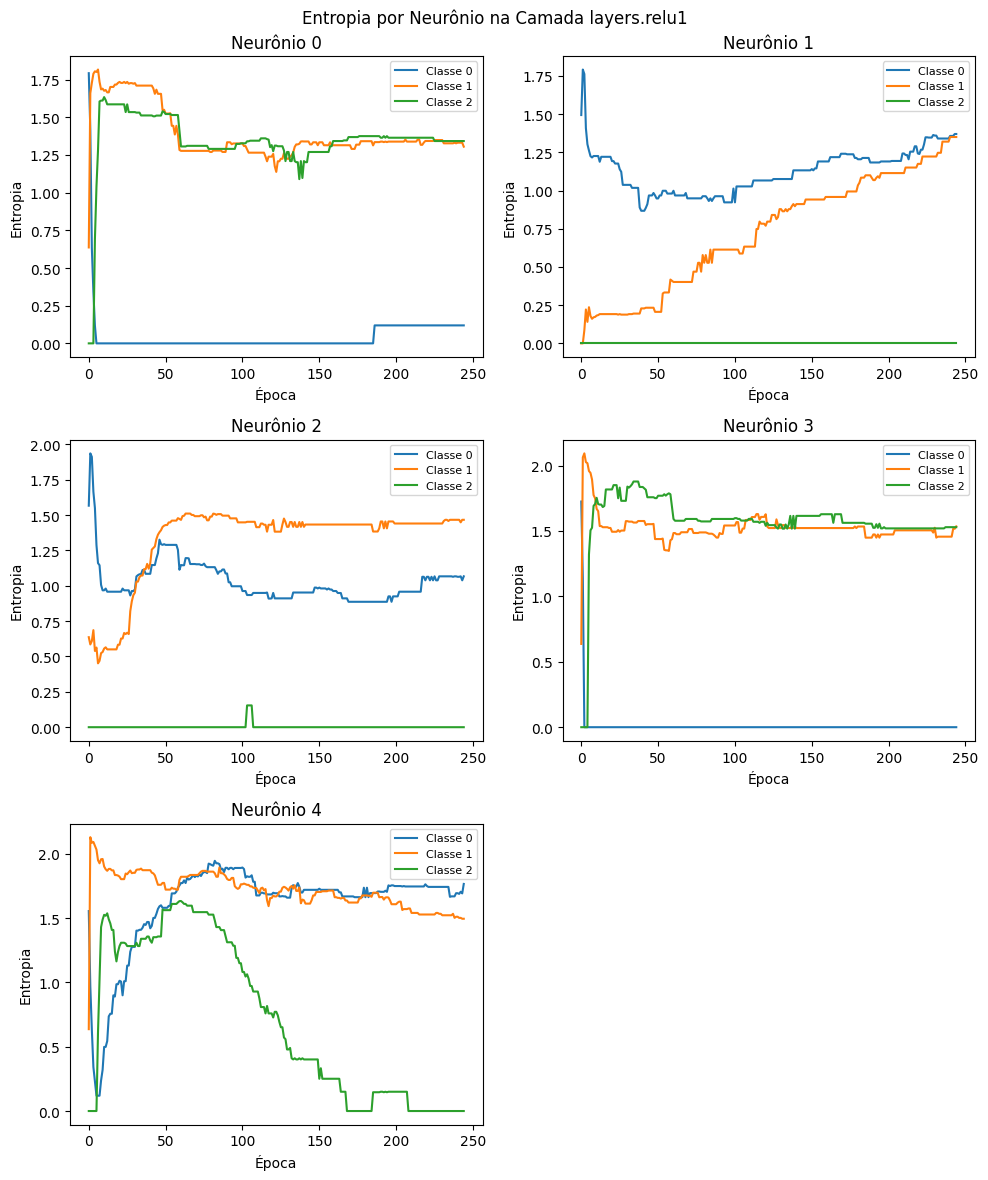

In [ ]:
student_entropy, classest = get_entropy_classes(student_entropy_history, log_activations_ordered)
layers = list(student_entropy.keys())
l1 = layers[0]
neurons = list(student_entropy[l1].keys())

n_neurons = len(neurons)
ncols = 2  # ajuste conforme preferir
nrows = int(np.ceil(n_neurons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, neuron in enumerate(neurons):
    ax = axes[i]
    for y in classest:
        ax.plot(student_entropy[l1][neuron][y], label=f'Classe {y}')
    ax.set_title(f'Neurônio {neuron}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Entropia')
    ax.legend(fontsize=8)

# remove eixos vazios se n_neurons não for múltiplo de ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f'Entropia por Neurônio na Camada {l1}')
plt.tight_layout()
plt.show()

In [ ]:
teacher_info = {'grads' : {}, 'output':[]}
student_info = {'grads' : {}, 'output':[]}
for i in range(len(log_teacher)):
    for key in log_teacher[i]['grads']:
        if key not in teacher_info['grads']:
            teacher_info['grads'][key] = []
        
        teacher_info['grads'][key].append(log_teacher[i]['grads'][key])
        if key in log_student[i]['grads']:
            if key not in student_info['grads']:
                student_info['grads'][key] = []
            student_info['grads'][key].append(log_student[i]['grads'][key])
    teacher_info['output'].append(log_teacher[i]['pred_labels'])
    student_info['output'].append(log_student[i]['pred_labels'])

for key in teacher_info['grads']:
    teacher_info['grads'][key] = torch.cat(teacher_info['grads'][key], dim=0)
    if key in student_info['grads']:
        student_info['grads'][key] = torch.cat(student_info['grads'][key], dim=0)

teacher_info['output'] = torch.cat(teacher_info['output'], dim=0)
student_info['output'] = torch.cat(student_info['output'], dim=0)

In [ ]:
idteacher = np.argsort(teacher_info['output'].cpu().numpy())
idstudent = np.argsort(student_info['output'].cpu().numpy())

for key in teacher_info['grads']:
    teacher_info['grads'][key] = teacher_info['grads'][key][idteacher]
    if key in student_info['grads']:
        student_info['grads'][key] = student_info['grads'][key][idstudent]

teacher_info['output'] = teacher_info['output'][idteacher]
student_info['output'] = student_info['output'][idstudent]

In [ ]:
from pruning_utils import compute_similarity_matrix

In [ ]:
teacher_sim_matrix = {}
student_sim_matrix = {}
for key in teacher_info['grads']:
    if 'bias' in key:
        continue
    teacher_sim_matrix[key] = compute_similarity_matrix(teacher_info['grads'][key])
    if key in student_info['grads']:
        student_sim_matrix[key] = compute_similarity_matrix(student_info['grads'][key])
        

In [68]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, fname):
    """
    Plots similarity matrices for each neuron of each layer,
    comparing teacher (left) vs student (right).

    Args:
        teacher_sim_matrix: dict {layer_key: tensor of shape (N_teacher, nsamples, nsamples)}
        student_sim_matrix: dict {layer_key: tensor of shape (N_student, nsamples, nsamples)}
    """
    for layer_key in teacher_sim_matrix:
        t_mats = teacher_sim_matrix[layer_key]  # (N_t, S, S)
        if layer_key in student_sim_matrix:
            s_mats = student_sim_matrix[layer_key]  # (N_s, S, S)

        # Convert to numpy if tensors
        if hasattr(t_mats, 'cpu'):
            t_mats = t_mats.cpu().numpy()
            if layer_key in student_sim_matrix:
                s_mats = s_mats.cpu().numpy()

        n_teacher = t_mats.shape[0]
        n_student = s_mats.shape[0]
        n_cols    = max(n_teacher, n_student)

        fig = plt.figure(figsize=(3.5 * n_cols, 7))
        fig.suptitle(f"Layer: {layer_key}", fontsize=14, fontweight='bold', y=1.01)

        # Two rows: teacher on top, student on bottom
        outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45)

        for row_idx, (label, mats, n_neurons) in enumerate([
            ("Teacher", t_mats, n_teacher),
            ("Student", s_mats, n_student),
        ]):
            inner = gridspec.GridSpecFromSubplotSpec(
                1, n_cols, subplot_spec=outer[row_idx], wspace=0.3
            )

            for neuron_idx in range(n_cols):
                ax = fig.add_subplot(inner[neuron_idx])

                if neuron_idx < n_neurons:
                    mat = mats[neuron_idx]
                    vmin, vmax = mat.min(), mat.max()
                    im = ax.imshow(mat, aspect='auto', cmap='viridis',
                                   vmin=vmin, vmax=vmax, interpolation='nearest')
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                    ax.set_title(f"Neuron {neuron_idx}", fontsize=9)
                    ax.set_xlabel("Sample", fontsize=7)
                    ax.set_ylabel("Sample", fontsize=7)
                    ax.tick_params(labelsize=6)
                else:
                    # Pad empty slots so grids align between teacher/student
                    ax.axis('off')
                    ax.set_facecolor('#f0f0f0')

                # Row label only on the first column
                if neuron_idx == 0:
                    ax.set_ylabel(f"{label}\nSample", fontsize=8, fontweight='bold')

        plt.tight_layout()
        plt.savefig(f"{fname}_{layer_key}.png", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname}_{layer_key}.png")


# ── run ───────────────────────────────────────────────────────────────────────
plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, "prof55student5_v2")

NameError: name 'teacher_sim_matrix' is not defined